# Question 4

-	gibt es tage im jahr an denen die illegale müllentsorgung und/oder graphiti aktivität in zürich besonders hoch ist. korreliert dies mit besonderen events (fussball, konzerte), welche für die entsorgung verantwortlich gemacht werden können

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import datetime as dt
import numpy as np
from scipy import stats

## access and load data

In [3]:
#Access and load the züri wie neu data via API

url_zwn = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Zueri_wie_neu?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=zwn_meldungen_p"
response_zwn = requests.get(url_zwn)
if response_zwn.status_code == 200:
    print("Data züri wie neu loaded sugessfull")
    zwn_gdf = gpd.read_file(response_zwn.url).set_crs(epsg="4326").to_crs(epsg="2056")
else:
    print("Data züri wie neu loading failed")

Data züri wie neu loaded sugessfull


## filter data


In [39]:
zwn_filtered_gdf = zwn_gdf[["requested_datetime", "service_name", "geometry", "title"]]
zwn_filtered_gdf = zwn_filtered_gdf[zwn_filtered_gdf["service_name"]=="Abfall/Sammelstelle"]
zwn_filtered_gdf.head(5)


,requested_datetime,service_name,geometry,title
4,2013-03-15 10:36:53,Abfall/Sammelstelle,POINT (2683094.025 1247762.007),Arbeitskist
32,2013-04-04 13:21:06,Abfall/Sammelstelle,POINT (2681647.035 1244209.988),Schmiererei
43,2013-04-16 14:49:45,Abfall/Sammelstelle,POINT (2683318.013 1247968.969),Dieses defe
56,2013-04-16 17:28:32,Abfall/Sammelstelle,POINT (2681835.03 1249416.051),Defektes Ve
68,2013-04-17 07:55:59,Abfall/Sammelstelle,POINT (2678259 1252071.053),Bitte Abfal


## aggregate

In [40]:
zwn_filtered_gdf["date"] = zwn_filtered_gdf["requested_datetime"].dt.date

zwn_count_per_date = zwn_filtered_gdf["date"].value_counts()
zwn_count_per_date_month = zwn_count_per_date[zwn_count_per_date.index > pd.to_datetime('2026-04-01').date()]
zwn_count_per_date_month = zwn_count_per_date_month.sort_index()
zwn_count_per_date_month.head(5)

date
2026-04-02    11
2026-04-03     4
2026-04-04    10
2026-04-05    20
2026-04-06    22
Name: count, dtype: int64

## plot

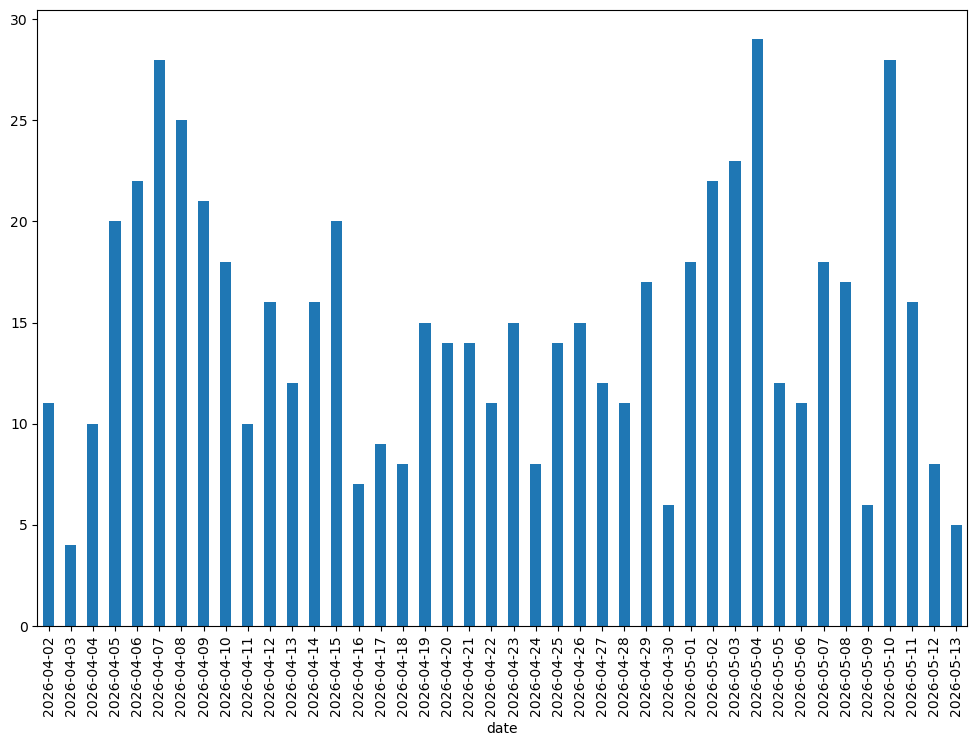

In [41]:
fig, ax = plt.subplots(figsize= (12,8))
zwn_count_per_date_month.plot(ax=ax, kind="bar" )
plt.show()